# **3. Phase: Model Selection, Training, and Validation**

This phase builds directly upon the findings of Phase 2. In the previous stage, our statistical tests (ADF and KPSS) confirmed that the daily PJME energy consumption data is stationary, meaning its mean and variance remain stable over time ($d=0$). Furthermore, our ACF and PACF analysis identified a dominant 7-day seasonal cycle, which is characteristic of human weekly activity patterns.

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm
from pmdarima import auto_arima

load_dotenv()
DAILY_FILE_ID = os.getenv("PJME_DAILY_FILE_ID")

url = f"https://drive.google.com/uc?id={DAILY_FILE_ID}"
pjme_daily = pd.read_csv(url)

if 'Datetime' in pjme_daily.columns:
    date_col = 'Datetime'
else:
    date_col = pjme_daily.columns[0]

pjme_daily[date_col] = pd.to_datetime(pjme_daily[date_col]) # convert datetime to a format the computer understands
pjme_daily.set_index(date_col, inplace=True)
pjme_daily.index.name = 'Datetime' # set the date as index so we can track values over time

pjme_daily = pjme_daily.asfreq('D') # set frequency for model

null_count = pjme_daily.isnull().sum().sum()
print(f"Missing values after frequency alignment: {null_count}") # quick check to make sure data is continous

print(pjme_daily.head())

Missing values after frequency alignment: 0
                    PJME
Datetime                
2002-01-01  31080.739130
2002-01-02  34261.541667
2002-01-03  34511.875000
2002-01-04  33715.458333
2002-01-05  30405.125000


# **Train/test split**

We divide the dataset into two distinct 4-year windows to compare energy patterns across different decades. This helps us see if the consumption behavior has changed over time.

-Early Era (2002–2005)

-Late Era (2014–2017)

For each era, we use the first 3 years for training and the final year for testing.

Data split:
Early Era (2002-2005): 1096 Train days | 365 Test days
Late Era  (2014-2017): 1096 Train days | 365 Test days


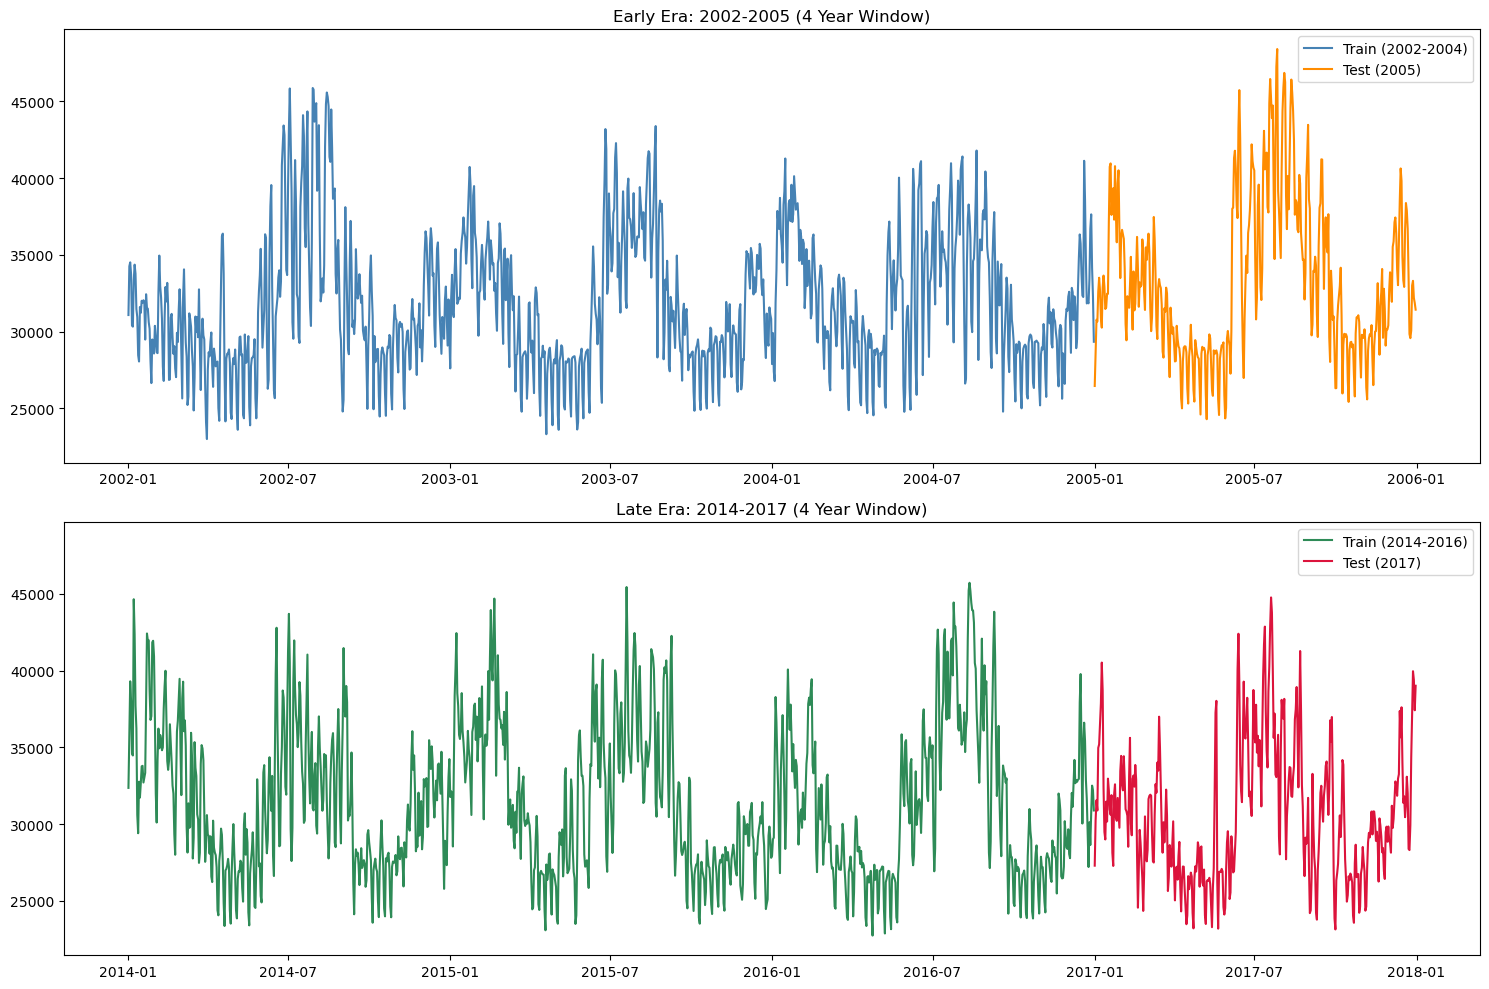

In [15]:
# first split: 2002 to 2005 (4 Years)
df_early = pjme_daily.loc['2002-01-01':'2005-12-31']
train_early = df_early.loc[:'2004-12-31']
test_early = df_early.loc['2005-01-01':]

# second split: 2014 to 2017 (4 Years)
df_late = pjme_daily.loc['2014-01-01':'2017-12-31']
train_late = df_late.loc[:'2016-12-31']
test_late = df_late.loc['2017-01-01':]

print("Data split:")
print(f"Early Era (2002-2005): {len(train_early)} Train days | {len(test_early)} Test days")
print(f"Late Era  (2014-2017): {len(train_late)} Train days | {len(test_late)} Test days")

fig, ax = plt.subplots(2, 1, figsize=(15, 10), sharey=True)

# early era plot
ax[0].plot(train_early.index, train_early.iloc[:, 0], label='Train (2002-2004)', color='steelblue')
ax[0].plot(test_early.index, test_early.iloc[:, 0], label='Test (2005)', color='darkorange')
ax[0].set_title('Early Era: 2002-2005 (4 Year Window)')
ax[0].legend()

# late era plot
ax[1].plot(train_late.index, train_late.iloc[:, 0], label='Train (2014-2016)', color='seagreen')
ax[1].plot(test_late.index, test_late.iloc[:, 0], label='Test (2017)', color='crimson')
ax[1].set_title('Late Era: 2014-2017 (4 Year Window)')
ax[1].legend()

plt.tight_layout()
plt.show()

# **Model selection**

Based on the results from Phase 2, we chose a SARIMA (Seasonal AutoRegressive Integrated Moving Average) model. A standard ARIMA model only looks at short-term trends, but our data has a massive 7-day seasonal rhythm. SARIMA allows us to mathematically account for this weekly cycle ($m=7$).

We use auto_arima to find the most accurate settings for our model.Stationarity ($d=0$): We set this to 0 because Phase 2 proved the data is already stable. Seasonality ($m=7$): We set this to 7 to capture the weekly energy patterns. 

Goal: The algorithm searches for the settings that result in the the best balance between model simplicity and prediction accuracy.

In [16]:
# we use d=0 (stationary) and m=7 (weekly cycle)

print("searching for best SARIMA parameters for Early Era (2002-2004)...")
model_early = auto_arima(train_early, 
                         seasonal=True, m=7, 
                         stepwise=True, 
                         suppress_warnings=True, 
                         trace=True)

print("\nsearching for best SARIMA parameters for Late Era (2014-2016)...")
model_late = auto_arima(train_late, 
                        seasonal=True, m=7, 
                        stepwise=True, 
                        suppress_warnings=True, 
                        trace=True)

print("\n--- RESULTS ---")
print(f"Early Era Best Model: {model_early.order}x{model_early.seasonal_order}")
print(f"Late Era Best Model:  {model_late.order}x{model_late.seasonal_order}")

searching for best SARIMA parameters for Early Era (2002-2004)...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=3.01 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=21491.804, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=19969.463, Time=0.73 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=20279.525, Time=0.66 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=25860.746, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=20271.651, Time=0.06 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=19927.246, Time=3.09 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=19899.508, Time=3.29 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=19971.187, Time=0.96 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=inf, Time=2.89 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=19933.471, Time=1.11 sec
 ARIMA(0,0,0)(2,0,1)[7] intercept   : AIC=21060.991, Time=3.36 sec
 ARIMA(2,0,0)(2,0,1)[7] intercept   : AIC=19817.842, Time=3.29 sec


d:\anaconda\Lib\site-packages\pmdarima\arima\_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(2,0,0)(1,0,1)[7] intercept (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "d:\anaconda\Lib\site-packages\pmdarima\arima\_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
  File "d:\anaconda\Lib\site-packages\pmdarima\arima\arima.py", line 610, in fit
    self._fit(y, X, **fit_args)
  File "d:\anaconda\Lib\site-packages\pmdarima\arima\arima.py", line 531, in _fit
    fit, self.arima_res_ = _fit_wrapper()
                           ^^^^^^^^^^^^^^
  File "d:\anaconda\Lib\site-packages\pmdarima\arima\arima.py", line 517, in _fit_wrapper
    fitted = arima.fit(
             ^^^^^^^^^^
  File "d:\anaconda\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py", line 705, in fit
    mlefit = super().fit(start_params, method=method,
             ^^^^^^^^^^^^^^^^^^^^^^^^^^

 ARIMA(2,0,0)(1,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(2,0,0)(2,0,0)[7] intercept   : AIC=19859.587, Time=8.71 sec
 ARIMA(2,0,0)(2,0,2)[7] intercept   : AIC=20158.453, Time=2.72 sec
 ARIMA(2,0,0)(1,0,0)[7] intercept   : AIC=19884.610, Time=1.31 sec
 ARIMA(2,0,0)(1,0,2)[7] intercept   : AIC=19848.320, Time=1.54 sec
 ARIMA(3,0,0)(2,0,1)[7] intercept   : AIC=19746.198, Time=3.27 sec
 ARIMA(3,0,0)(1,0,1)[7] intercept   : AIC=19797.214, Time=1.13 sec
 ARIMA(3,0,0)(2,0,0)[7] intercept   : AIC=19753.672, Time=10.71 sec
 ARIMA(3,0,0)(2,0,2)[7] intercept   : AIC=inf, Time=3.36 sec
 ARIMA(3,0,0)(1,0,0)[7] intercept   : AIC=19801.596, Time=0.91 sec
 ARIMA(3,0,0)(1,0,2)[7] intercept   : AIC=19770.978, Time=1.79 sec
 ARIMA(4,0,0)(2,0,1)[7] intercept   : AIC=20567.496, Time=3.53 sec
 ARIMA(3,0,1)(2,0,1)[7] intercept   : AIC=21913.249, Time=1.06 sec
 ARIMA(2,0,1)(2,0,1)[7] intercept   : AIC=19777.135, Time=3.60 sec
 ARIMA(4,0,1)(2,0,1)[7] intercept   : AIC=inf, Time=4.56 sec
 ARIMA(3,0,0)

**Key Observation**: Both models kept the seasonal setting of $(2, 0, 1, 7)$. This proves that the weekly rhythm of energy usage (weekends vs. weekdays) remained very stable over the 15-year gap. The slight changes in the first set of numbers (non-seasonal) simply show that the day-to-day "momentum" of energy demand evolved slightly over time and became a bit more complex requiring the model to use error-correction to maintain accuracy.

Reminder of what these values mean on the example of Late Era model:

**Non-Seasonal Part: $(2, 0, 2)$** This describes the relationship between consecutive days.

$p = 2$ (Autoregressive): The model looks back at the actual energy values from the last 2 days.

$d = 0$ (Integrated): No differenecing - values were already stable (stationary).

$q = 2$ (Moving Average): The model looks at the prediction errors from the last 2 days to correct its current guess.

**Seasonal Part: $(2, 0, 1, 7)$** This describes the weekly rhythm (the 7-day cycle).

$P = 2$ (Seasonal AR): The model looks at the values from exactly 7 and 14 days ago.

$D = 0$ (Seasonal Integrated): No differenecing - values were already stable (stationary).

$Q = 1$ (Seasonal MA): The model corrects itself based on the error it made exactly 7 days ago.

$s = 7$ (Seasonality): This defines the length of the cycle (7 days for a week).

# **Residual Analysis**

To verify our model is working correctly, we examine the Residuals (the difference between what actually happened and what the model predicted). A "healthy" model should have residuals that look like White Noise - meaning the errors are completely random and contain no hidden patterns.

We are looking for three things:

Randomness: Errors should be scattered around zero.

Normality: Most errors should be small and centered at zero (Bell Curve).

Independence: No spikes in the ACF plot, proving the model captured all seasonal patterns.

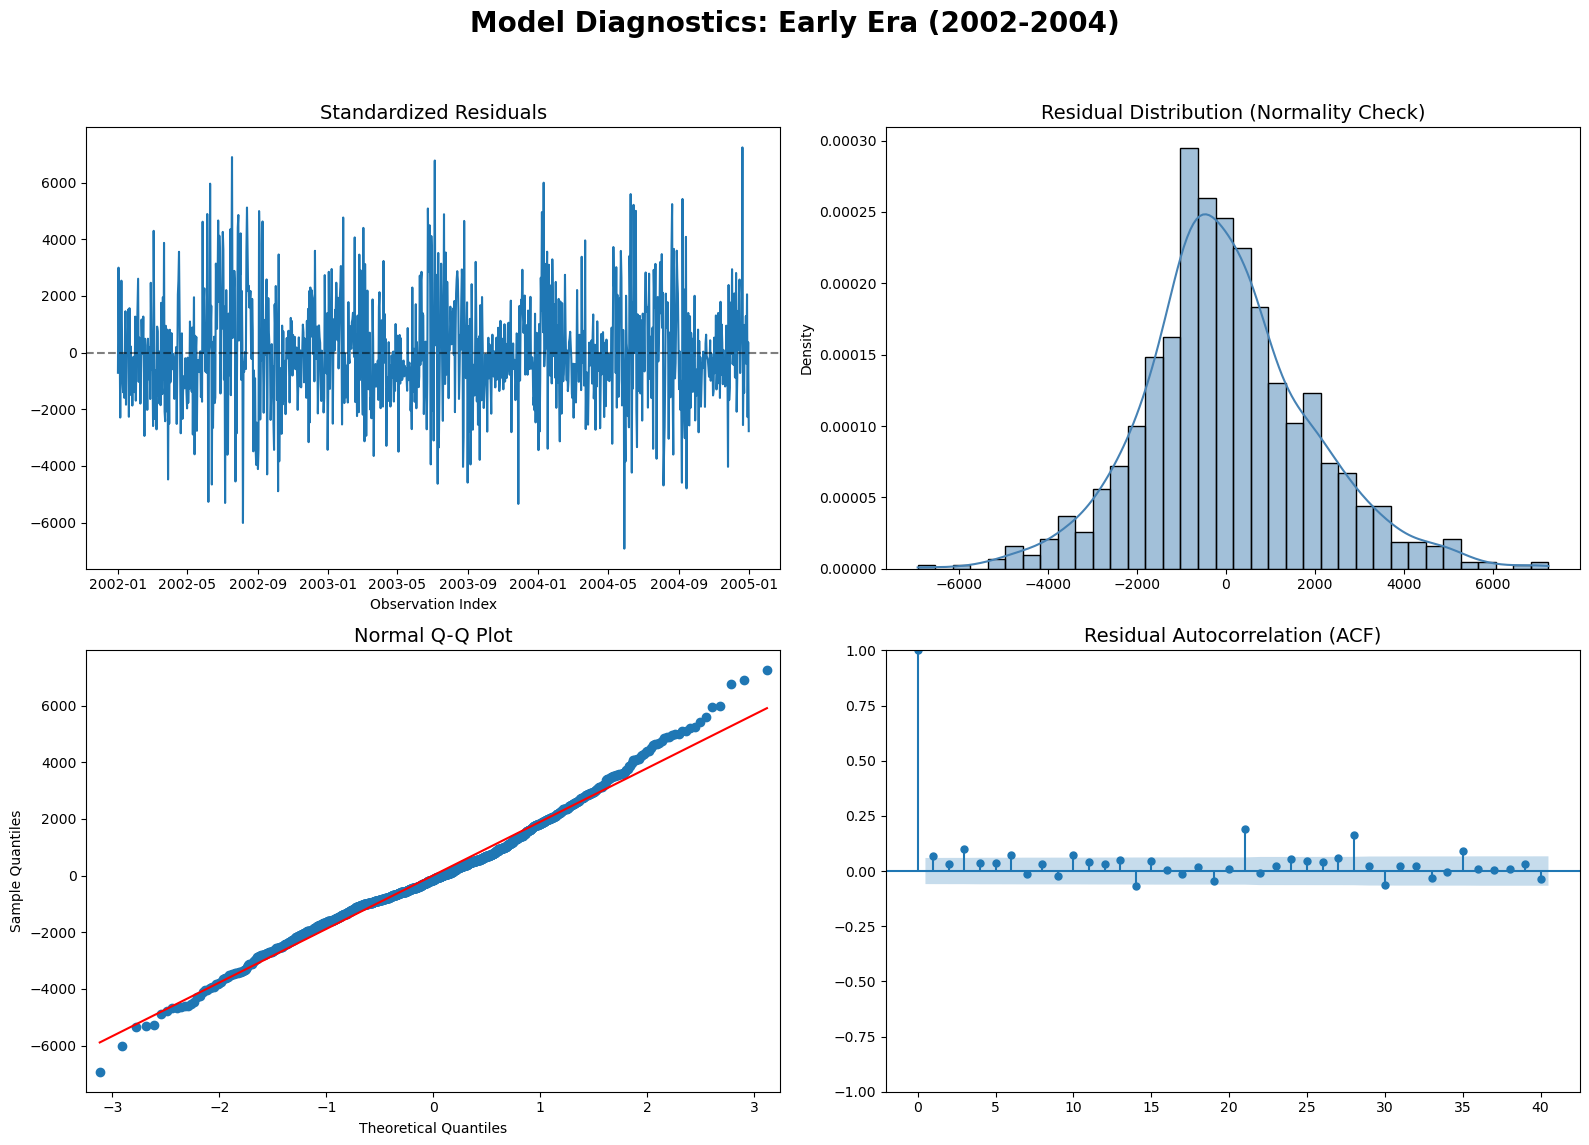

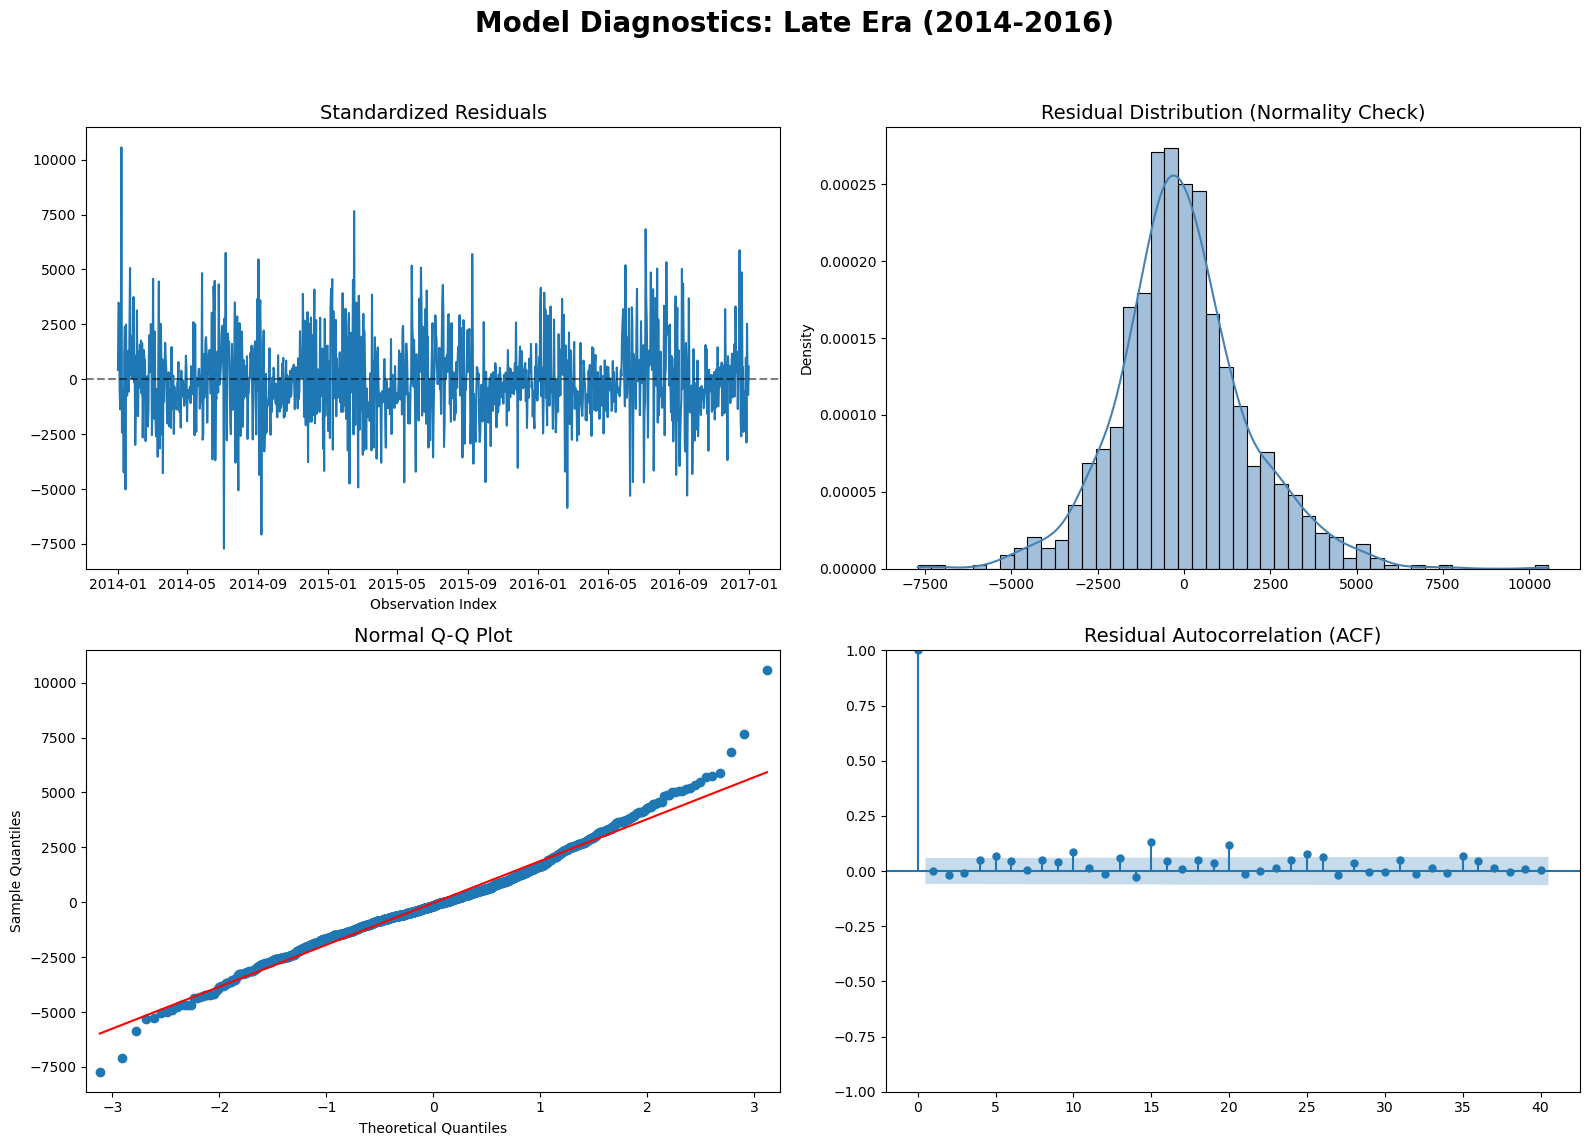

In [17]:
def plot_clean_diagnostics(model, title):
    # put the actual results into object from the pmdarima model
    results = model.arima_res_
    
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(title, fontsize=20, fontweight='bold')

    # standarized residuals
    axs[0, 0].plot(results.resid)
    axs[0, 0].set_title('Standardized Residuals', fontsize=14)
    axs[0, 0].axhline(0, color='black', linestyle='--', alpha=0.5)
    axs[0, 0].set_xlabel('Observation Index')

    # histogram plus estimated density
    sns.histplot(results.resid, kde=True, ax=axs[0, 1], color='steelblue', stat="density")
    axs[0, 1].set_title('Residual Distribution (Normality Check)', fontsize=14)

    # normal Q-Q plot
    qqplot(results.resid, line='s', ax=axs[1, 0])
    axs[1, 0].set_title('Normal Q-Q Plot', fontsize=14)

    # correlogram (ACF)
    plot_acf(results.resid, ax=axs[1, 1], lags=40)
    axs[1, 1].set_title('Residual Autocorrelation (ACF)', fontsize=14)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_clean_diagnostics(model_early, "Model Diagnostics: Early Era (2002-2004)")
plot_clean_diagnostics(model_late, "Model Diagnostics: Late Era (2014-2016)")

These plots confirm our models are statistically "healthy" and ready for forecasting. The model has extracted all usable information, leaving no predictable patterns behind.

Standardized Residuals & Correlogram (ACF): The residuals look like random static, and the ACF bars stay within the gray zone, proving the model successfully captured all the daily and weekly patterns.

Histogram & Q-Q plot: These show how well the errors follow a "Bell Curve". While most points follow the red line perfectly, the ends curve away because the model can't perfectly predict extreme, rare weather spikes.

In [18]:
final_model_early = model_early

print("\n\n\nEarly era model summary")
print(final_model_early.summary())




Early era model summary
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 1096
Model:             SARIMAX(3, 0, 0)x(2, 0, [1], 7)   Log Likelihood               -9865.099
Date:                             Wed, 28 Jan 2026   AIC                          19746.198
Time:                                     02:10:45   BIC                          19786.193
Sample:                                 01-01-2002   HQIC                         19761.331
                                      - 12-31-2004                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   5108.7997    982.130      5.202      0.000    3183.860    7033.739


Coefficient (coef) is essentially a weight that tells the model how much importance to give to a specific piece of past data when predicting today’s energy demand.

What is most important from this summary table is that all p-values are under 0.05 and most of them are 0.000. This is the proof that chosen lags are actually helping predict the energy demand and aren't just there by coincidence. The only exception is ar.S.L7 (0.420 meaning it is not statistically significant), which tells that for this specific era, looking back exactly 14 days was much more important than looking back 7 days.

The ar.L1 coefficient is 1.0088 with a massive z-score of 24.143. This indicates that the strongest predictor of today's energy load is simply what happened yesterday.

In [19]:
final_model_late = model_late

print("\n\nLate era model summary")
print(final_model_late.summary())



Late era model summary
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 1096
Model:             SARIMAX(2, 0, 2)x(2, 0, [1], 7)   Log Likelihood               -9842.570
Date:                             Wed, 28 Jan 2026   AIC                          19703.141
Time:                                     02:10:45   BIC                          19748.136
Sample:                                 01-01-2014   HQIC                         19720.166
                                      - 12-31-2016                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2446.0454      0.001   1.91e+06      0.000    2446.043    2446.048
ar

Once again, almost all p-values are under 0.05.

Unlike the early era, the ar.L1 predictor (yesterday’s load) is not statistically significant, with a p-value of 0.668. This suggests that by 2014, the daily "momentum" had weakened, and yesterday's demand alone was no longer a reliable predictor for today.

The ar.S.L7 term (exactly one week ago) has become a dominant predictor with a highly significant p-value of 0.000 and a strong coefficient of 0.7288